In [1]:
import numpy as np
import scipy.signal as signal
from matplotlib import pyplot as plt

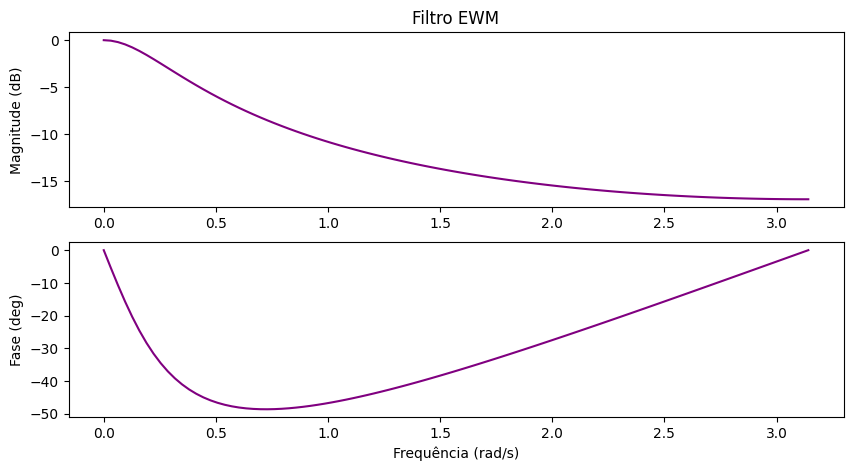

In [2]:
p = 7

alpha = 2/(1+p)

num = [alpha,0]
den = [1,-(1-alpha)]
dt = 1
fs = 1/(2*dt)

wmax = 100 #rad/s

H = signal.TransferFunction(num,den,dt=dt)


w = np.linspace(0,np.pi/dt,wmax)

w,h = signal.dfreqresp(H,w=w)

mag = 20*np.log10(abs(h))
ph = np.angle(h,deg=True)

fig,ax = plt.subplots(2,1,figsize=(10,5))

ax[0].set_title("Filtro EWM")
ax[0].plot(w,mag,color="purple")
ax[0].set_ylabel("Magnitude (dB)")



ax[1].plot(w,ph,color="purple")
ax[1].set_ylabel("Fase (deg)")
ax[1].set_xlabel("Frequência (rad/s)")

fig.savefig("../../imagens_gerais/filtro_ewm")

Entretanto, ambas são filtros e podem ser avaliadas no domínio da frequência. Na segunda imagem, é possível notar que a MM possui lóbulos, o que torna difícil de interpretá-la no domínio da frequência. Estes lóbulos atenuam algumas frequências mais do que outras.


Por outro lado, a EWM é um filtro passa-baixo simples e possui uma atenuação mais suave ao longo das frequências e menor atraso, o que faz com que  reaja mais rápido, e no domínio da frequência, possua comportamento mais compreensível. 


Mas nem tudo são flores: a EWM possui parâmetros mais difíceis de serem ajustados e é mais sensível a ruídos, como picos muito fortes. Já a MM, em essência, depende apenas da janela temporal escolhida. 

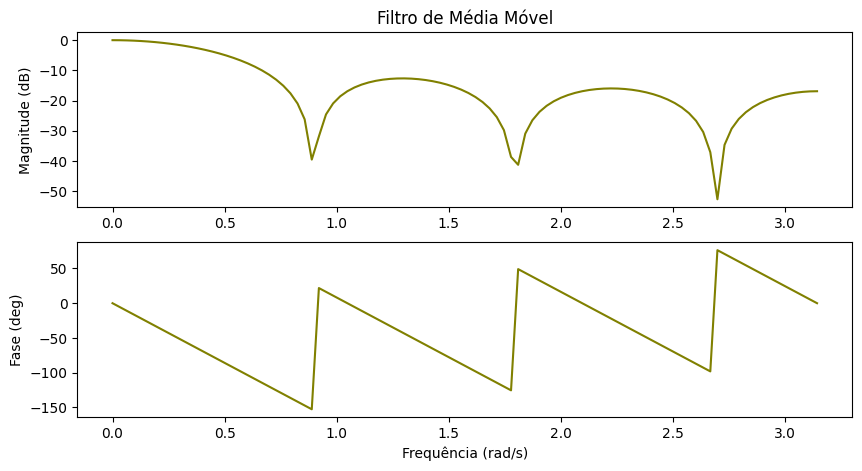

In [3]:
n = 7

num = np.ones(n)
den = np.insert(np.zeros(n-1),0,n)
dt = 1

wmax = 100 #rad/s

H = signal.TransferFunction(num,den,dt=dt)


w = np.linspace(0,np.pi/dt,wmax)

w,h = signal.dfreqresp(H,w=w)

mag = 20*np.log10(abs(h))
ph = np.angle(h,deg=True)

fig,ax = plt.subplots(2,1,figsize=(10,5))

ax[0].set_title("Filtro de Média Móvel")
ax[0].plot(w,mag,color="olive")
ax[0].set_ylabel("Magnitude (dB)")



ax[1].plot(w,ph,color="olive")
ax[1].set_ylabel("Fase (deg)")
ax[1].set_xlabel("Frequência (rad/s)")
fig.savefig("../../imagens_gerais/filtro_wma")

/tmp/ipykernel_9398/2023102845.py:16: RuntimeWarning: divide by zero encountered in log10
  mag = 20*np.log10(abs(h))


Text(0.5, 0, 'Frequência (rad/s)')

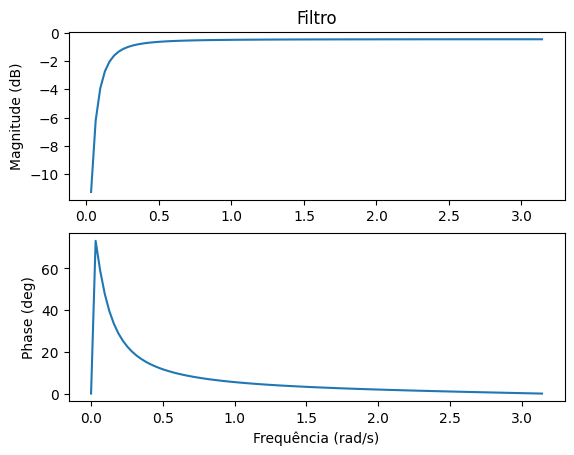

In [4]:
alpha = 0.1

num = [1-alpha,-(1-alpha)]
den = [1,-(1-alpha)]
dt = 1

wmax = 100 #rad/s

H = signal.TransferFunction(num,den,dt=dt)


w = np.linspace(0,np.pi/dt,wmax)

w,h = signal.dfreqresp(H,w=w)

mag = 20*np.log10(abs(h))
ph = np.angle(h,deg=True)

fig,ax = plt.subplots(2,1)

ax[0].set_title("Filtro")
ax[0].plot(w,mag)
ax[0].set_ylabel("Magnitude (dB)")



ax[1].plot(w,ph)
ax[1].set_ylabel("Phase (deg)")
ax[1].set_xlabel("Frequência (rad/s)")

/tmp/ipykernel_9398/2570073935.py:26: RuntimeWarning: divide by zero encountered in log10
  magW = 20*np.log10(abs(hw))


FileNotFoundError: [Errno 2] No such file or directory: '../imagens_gerais/filters.jpg'

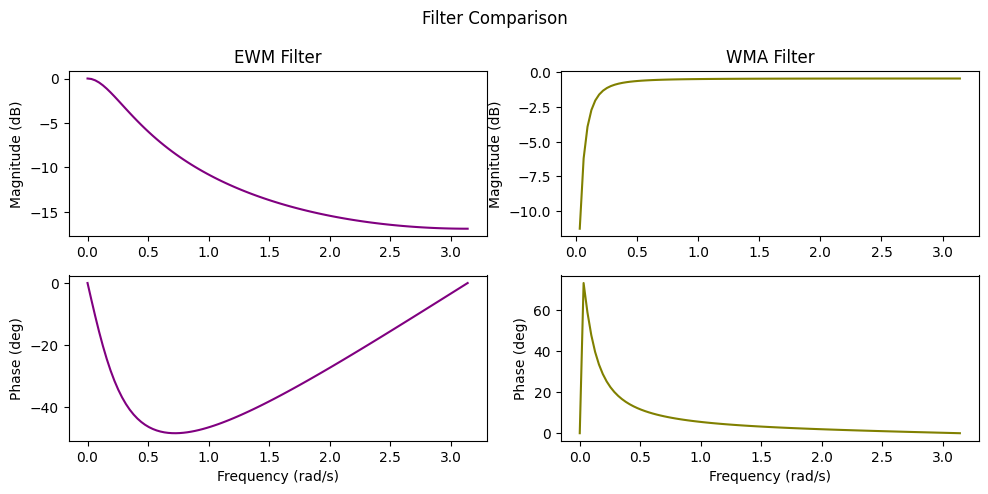

In [5]:
n = 7
alpha = 2/(n+1)

wmax = 100 #rad/s
w = np.linspace(0,np.pi/dt,wmax)
dt = 1

denE = [1,-(1-alpha)]
numE = [alpha,0]

numW = np.ones(n)
denW = np.insert(np.zeros(n-1),0,n)


He = signal.TransferFunction(numE,denE,dt=dt)
Hw = signal.TransferFunction(numW,denW,dt=dt)


we,he = signal.dfreqresp(He,w=w)
ww,hw = signal.dfreqresp(H,w=w)

magE = 20*np.log10(abs(he))
phE = np.angle(he,deg=True)


magW = 20*np.log10(abs(hw))
phW = np.angle(hw,deg=True)

fig,ax = plt.subplots(2,2,figsize=(10,5))

ax[0,0].set_title("EWM Filter")
ax[0,0].plot(w,magE, color="purple")
ax[0,0].set_ylabel("Magnitude (dB)")



ax[1,0].plot(w,phE, color="purple")
ax[1,0].set_ylabel("Phase (deg)")
ax[1,0].set_xlabel("Frequency (rad/s)")


ax[0,1].set_title("WMA Filter")
ax[0,1].plot(w,magW, color="olive")
ax[0,1].set_ylabel("Magnitude (dB)")



ax[1,1].plot(w,phW,color="olive")
ax[1,1].set_ylabel("Phase (deg)")
ax[1,1].set_xlabel("Frequency (rad/s)")
plt.suptitle("Filter Comparison")

plt.tight_layout(pad=1.12)

plt.savefig("../imagens_gerais/filters.jpg")

Text(0.5, 0, 'Frequency (rad/s)')

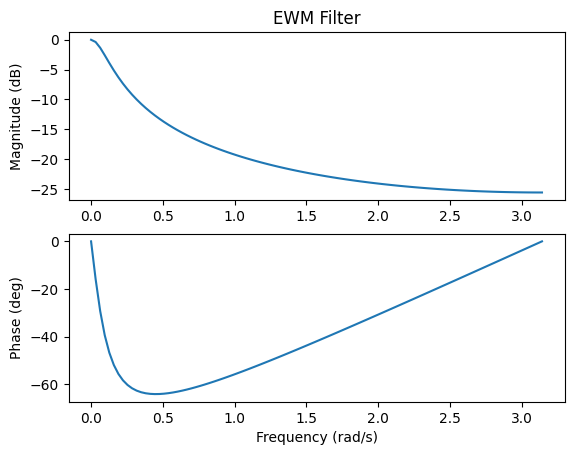

In [ ]:
alpha = 0.1

num = [alpha,0]
den = [1,-(1-alpha)]
dt = 1

wmax = 100 #rad/s

H = signal.TransferFunction(num,den,dt=dt)


w = np.linspace(0,np.pi/dt,wmax)

w,h = signal.dfreqresp(H,w=w)

mag = 20*np.log10(abs(h))
ph = np.angle(h,deg=True)

fig,ax = plt.subplots(2,1)

ax[0].set_title("EWM Filter")
ax[0].plot(w,mag)
ax[0].set_ylabel("Magnitude (dB)")



ax[1].plot(w,ph)
ax[1].set_ylabel("Phase (deg)")
ax[1].set_xlabel("Frequency (rad/s)")

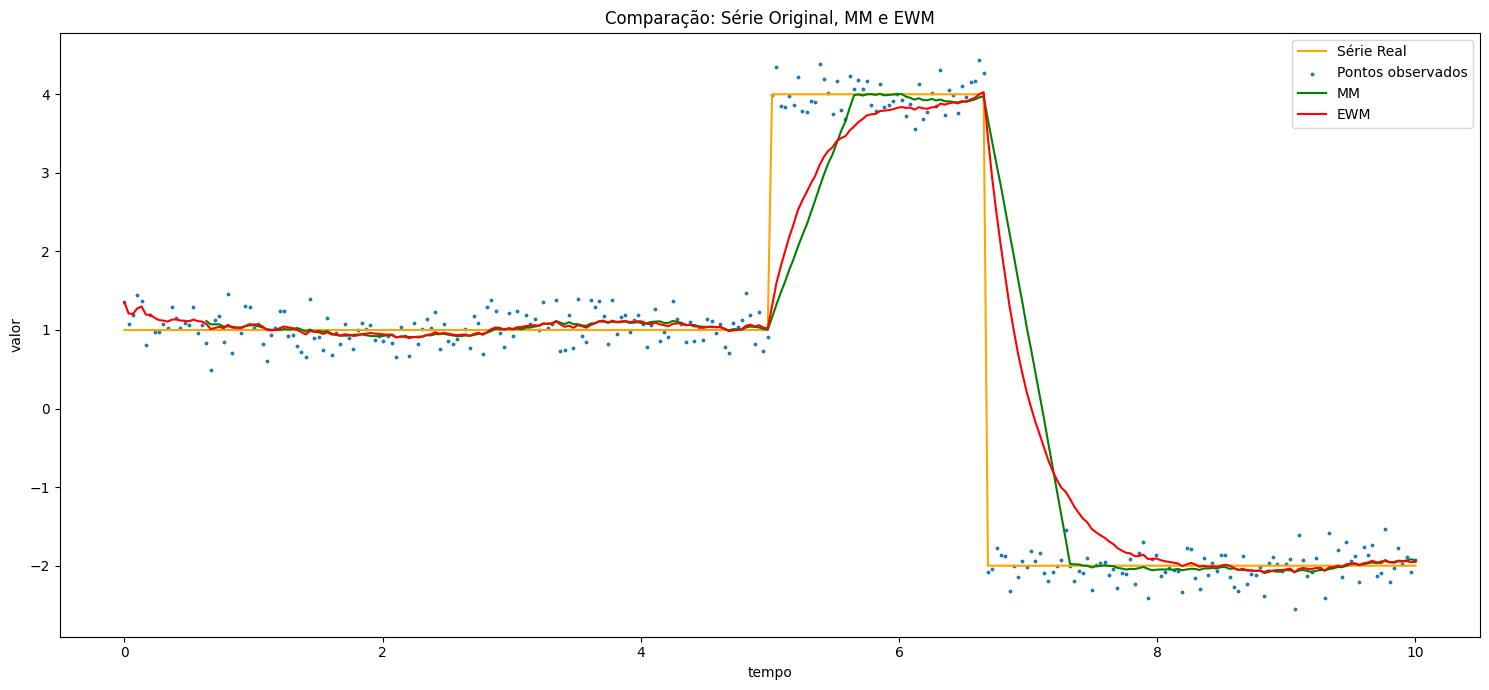

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# generate synthetic series
np.random.seed(0)
n = 300
x = np.linspace(0, 10, n)
base = np.ones(n)
base[n//2:] += 3*np.ones(n//2)

base[2*n//3:] -= 6*np.ones(n//3)

serie_ruido = base  + 0.2*np.random.randn(n)

# compute SMA and EWM
window = 20
sma = pd.Series(serie_ruido).rolling(window=window).mean()

ewm = pd.Series(serie_ruido).ewm(span=window).mean()

# plot
plt.figure(figsize=(15,7))

plt.plot(x,base, label='Série Real',color="orange")

plt.scatter(x,serie_ruido, label='Pontos observados', s = 3)

plt.plot(x,sma, label='MM',color="green")
plt.plot(x,ewm, label='EWM',color="red")
plt.legend()
plt.title("Comparação: Série Original, MM e EWM")
plt.xlabel("tempo")
plt.ylabel("valor")
plt.tight_layout()
plt.savefig("../../imagens_gerais/sma_ewm")
